In [10]:
# CELL 1: Imports and Setup
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add the src directory to the Python path so we can import our config
sys.path.append(os.path.abspath(os.path.join('..')))
from src.config import RAW_MAESTRO_DIR, PLOTS_DIR, PROXY_GENRES

# Set plotting style for report-ready figures
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300})

print("Environment setup complete. Ready for EDA.")

Environment setup complete. Ready for EDA.


In [11]:
# CELL 2: Load Data and Map Proxy Genres
# Note: You must have the MAESTRO dataset downloaded and extracted in data/raw_maestro/
# The metadata file is typically named maestro-v3.0.0.csv
metadata_path = RAW_MAESTRO_DIR / "maestro-v3.0.0.csv"

if not metadata_path.exists():
    print(f"WARNING: Metadata file not found at {metadata_path}.")
    print("Please download the MAESTRO MIDI-only dataset and place the CSV here.")
else:
    df = pd.read_csv(metadata_path)
    print(f"Successfully loaded MAESTRO metadata. Total tracks: {len(df)}")
    
    # Define a mapping dictionary to derive proxy genres from composers
    # This satisfies the Task 2 multi-genre requirement using a single dataset
    genre_mapping = {
        "Johann Sebastian Bach": "Baroque",
        "Domenico Scarlatti": "Baroque",
        "George Frideric Handel": "Baroque",
        
        "Wolfgang Amadeus Mozart": "Classical",
        "Joseph Haydn": "Classical",
        "Ludwig van Beethoven": "Classical",
        
        "Frédéric Chopin": "Romantic",
        "Franz Liszt": "Romantic",
        "Johannes Brahms": "Romantic",
        "Franz Schubert": "Romantic",
        "Robert Schumann": "Romantic",
        "Felix Mendelssohn": "Romantic",
        
        "Claude Debussy": "Impressionist_Modern",
        "Maurice Ravel": "Impressionist_Modern",
        "Alexander Scriabin": "Impressionist_Modern",
        "Sergei Rachmaninoff": "Impressionist_Modern",
        "Isaac Albéniz": "Impressionist_Modern"
    }
    
    # Apply mapping, defaulting to 'Other' if composer isn't in our main list
    df['proxy_genre'] = df['canonical_composer'].map(genre_mapping).fillna('Other')
    
    # Filter out 'Other' for our specific multi-genre tasks to keep distributions clean
    df_filtered = df[df['proxy_genre'] != 'Other'].copy()
    print(f"Tracks after filtering for specific proxy genres: {len(df_filtered)}")

Successfully loaded MAESTRO metadata. Total tracks: 1276
Tracks after filtering for specific proxy genres: 1172


C:\Users\User\AppData\Local\Temp\ipykernel_19328\1886190956.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_filtered, x='proxy_genre', order=PROXY_GENRES, palette='viridis')


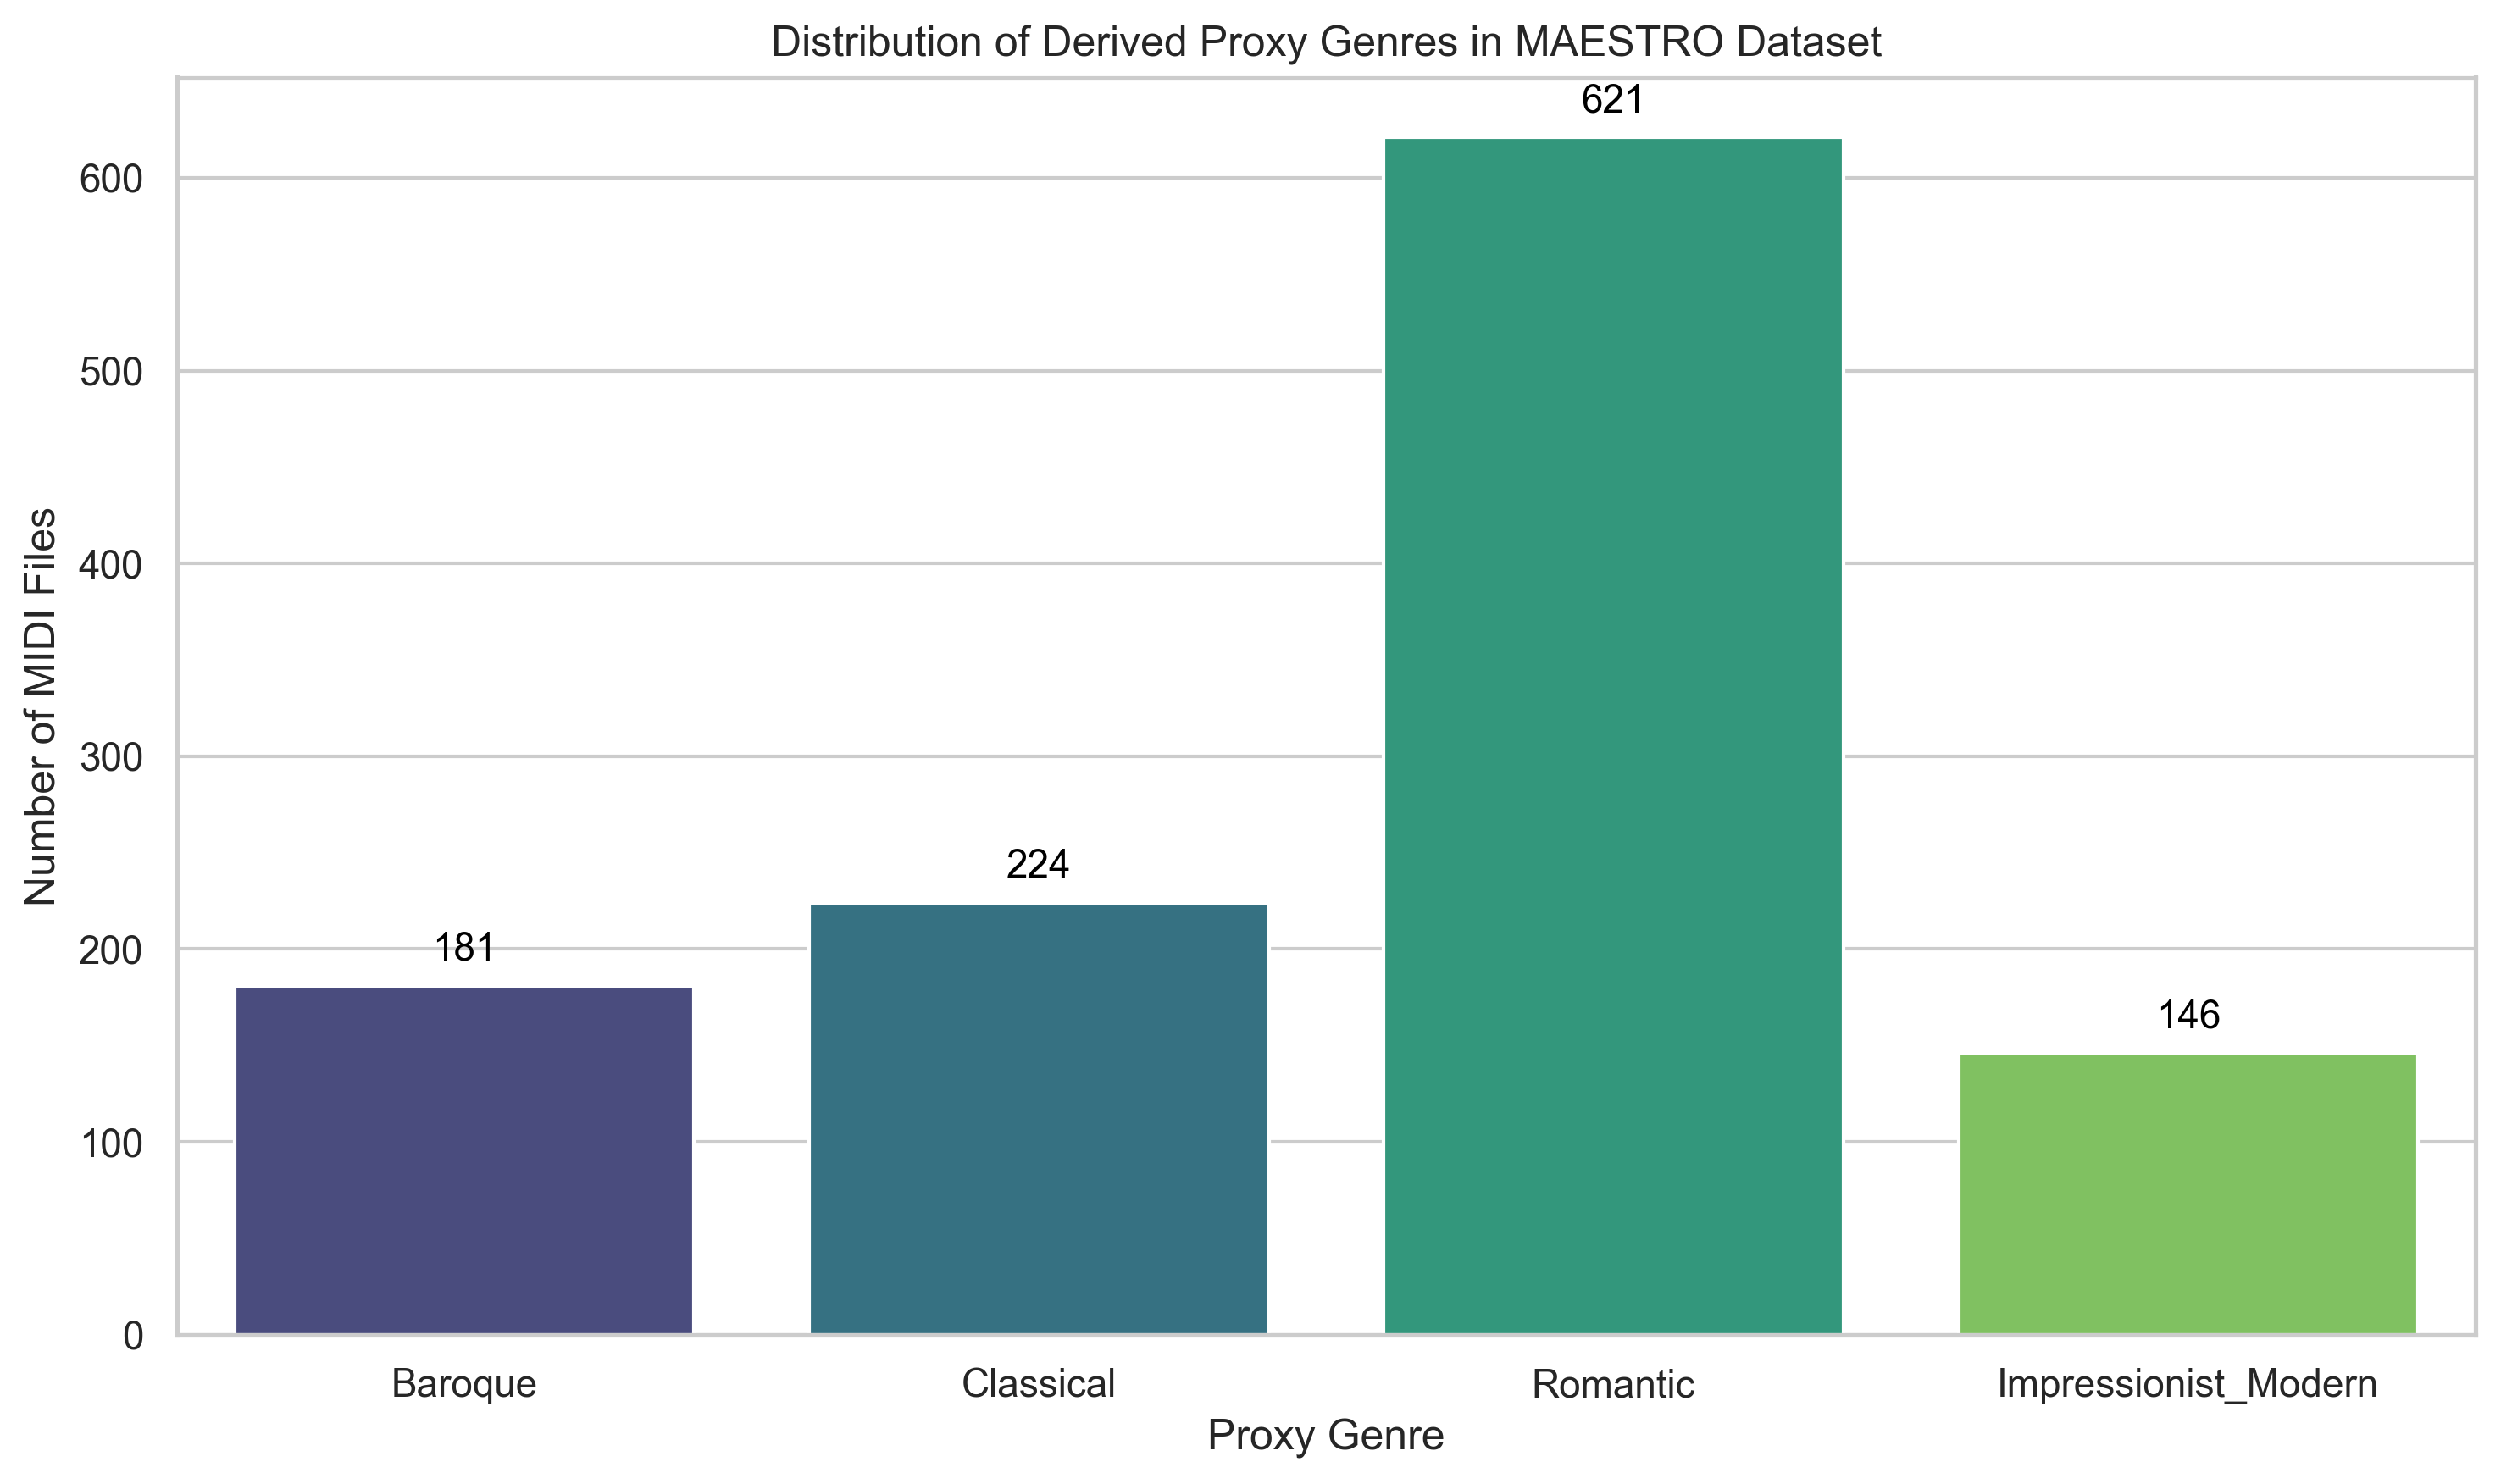

Saved genre distribution plot to Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\plots\eda_genre_distribution.png


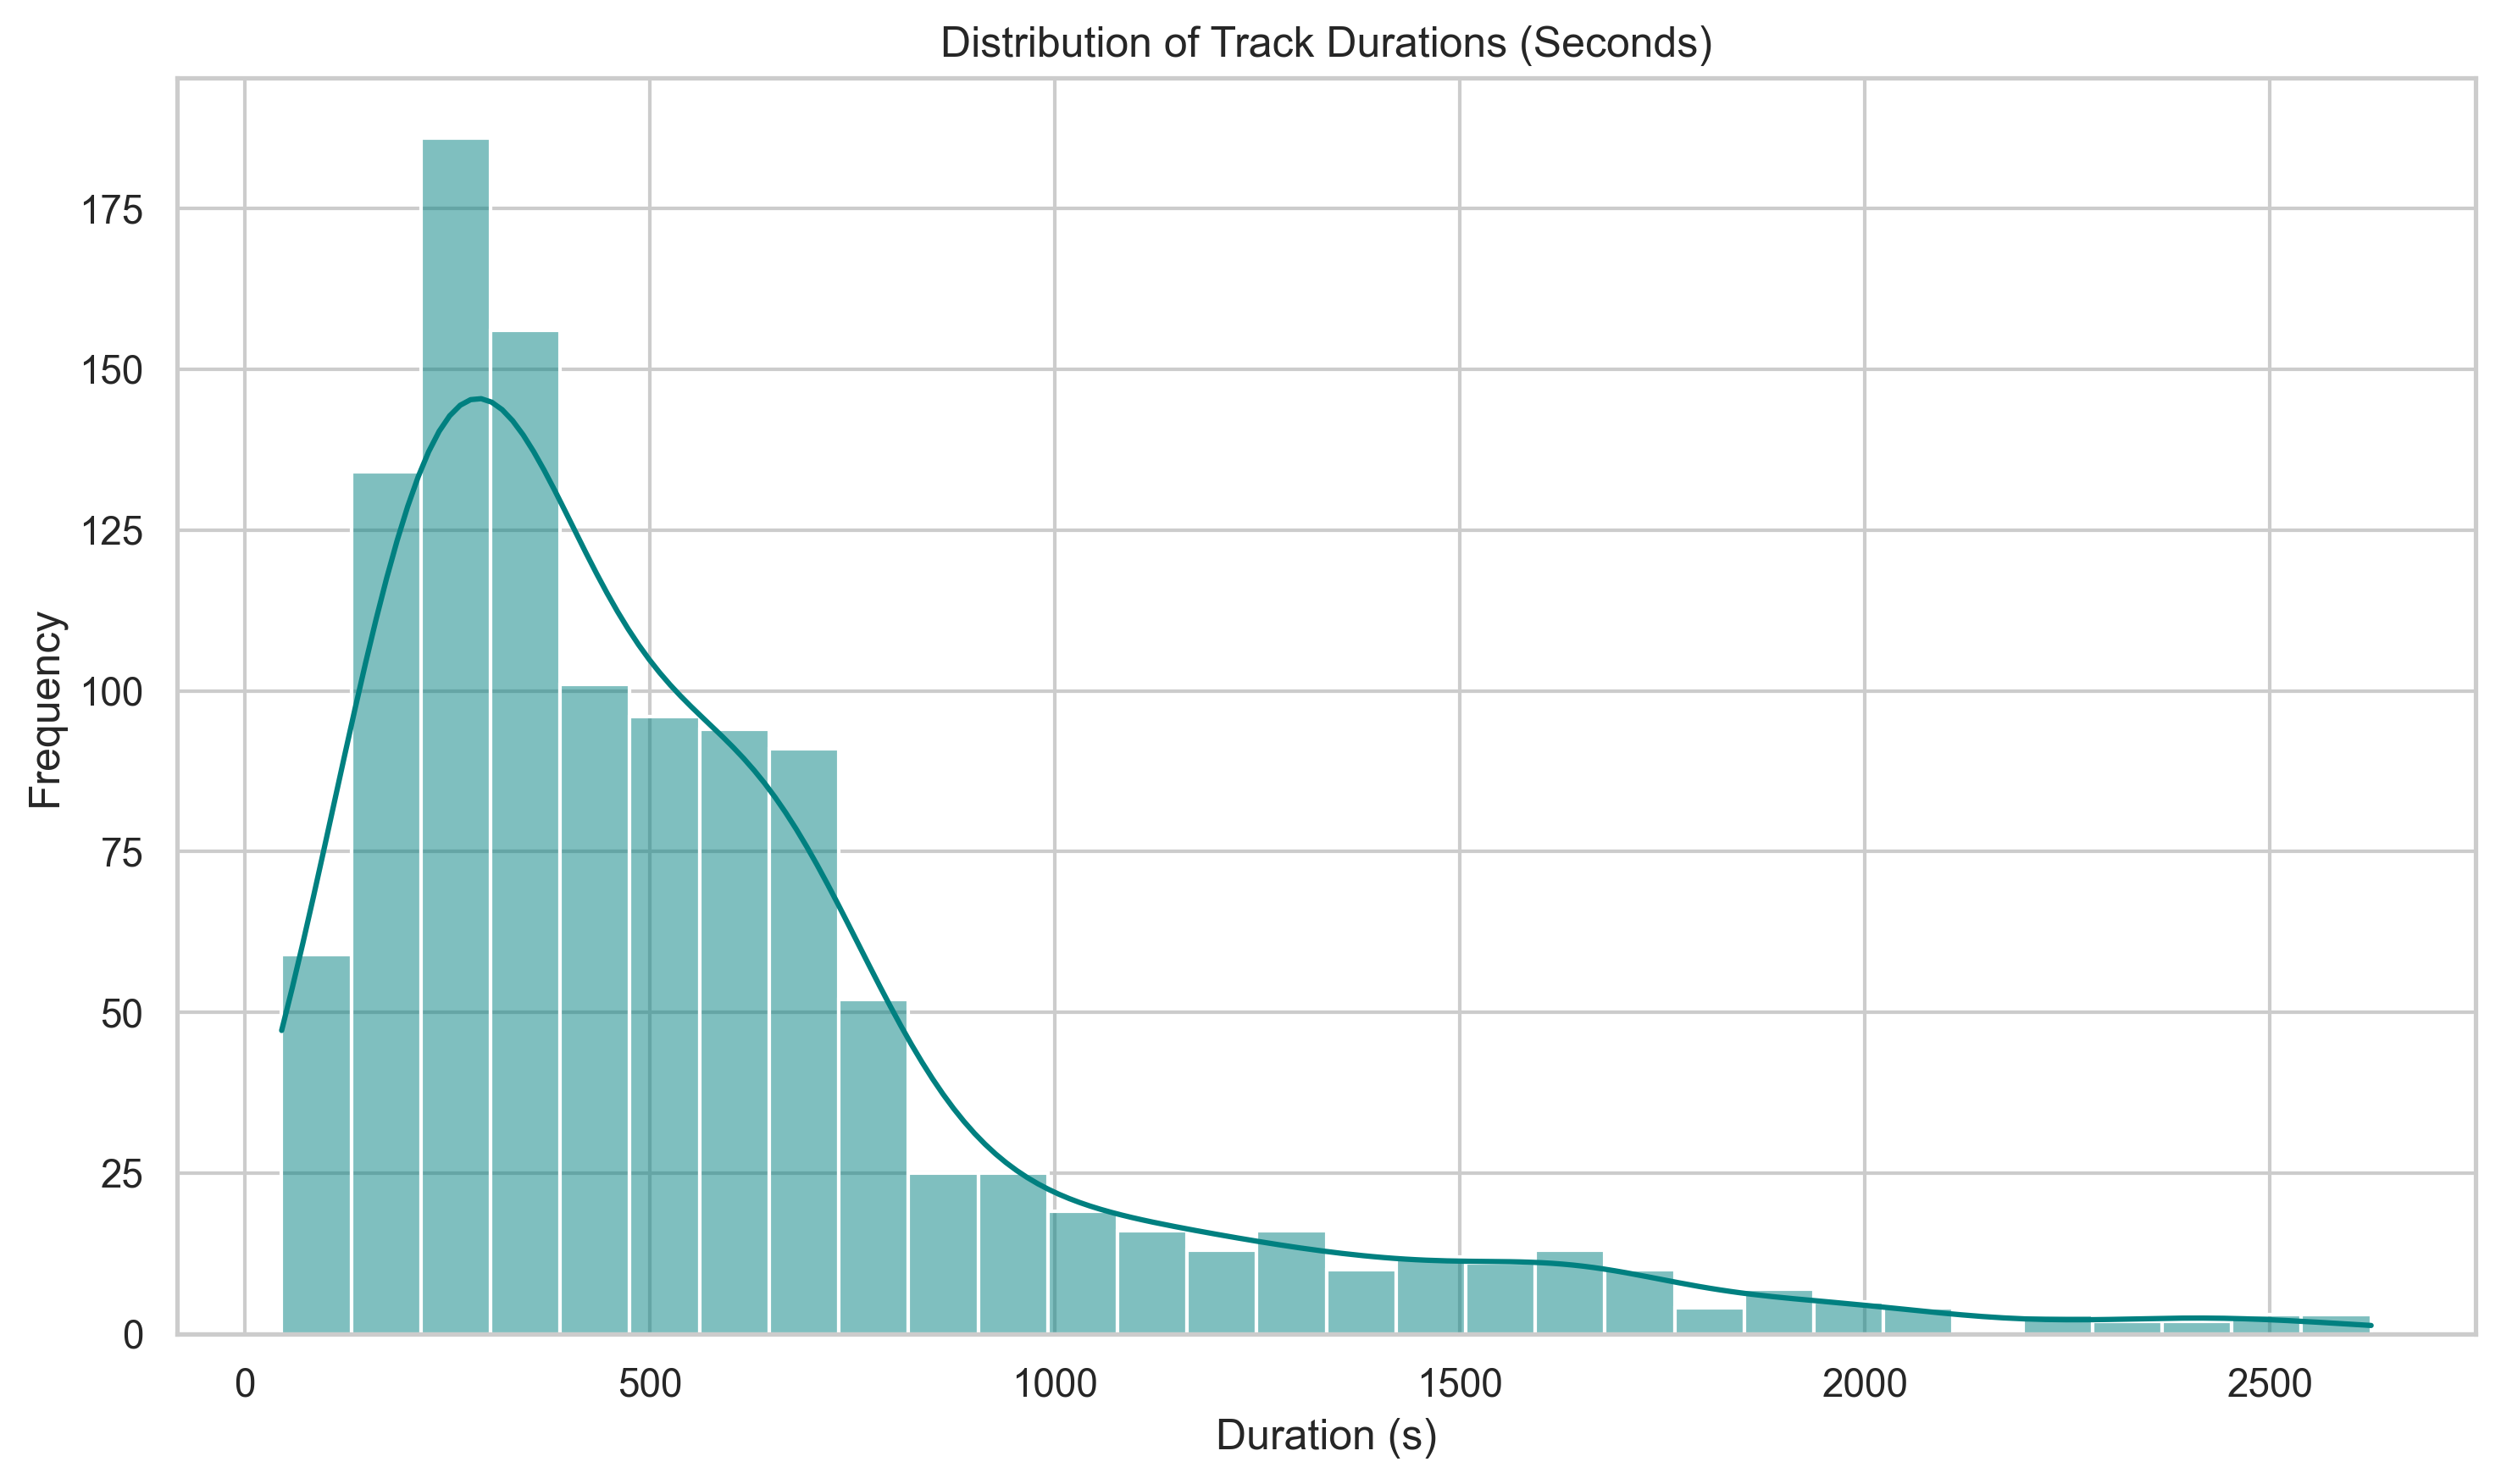

Saved duration distribution plot to Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\plots\eda_duration_distribution.png


In [12]:
# CELL 3: Generate and Save Report Figures
if 'df_filtered' in locals():
    # 1. Distribution of Proxy Genres
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df_filtered, x='proxy_genre', order=PROXY_GENRES, palette='viridis')
    plt.title("Distribution of Derived Proxy Genres in MAESTRO Dataset")
    plt.xlabel("Proxy Genre")
    plt.ylabel("Number of MIDI Files")
    
    # Add count labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                    textcoords='offset points')
        
    plt.tight_layout()
    genre_plot_path = PLOTS_DIR / "eda_genre_distribution.png"
    plt.savefig(genre_plot_path)
    plt.show()
    print(f"Saved genre distribution plot to {genre_plot_path}")

    # 2. Distribution of Track Durations
    plt.figure(figsize=(10, 6))
    sns.histplot(df_filtered['duration'], bins=30, kde=True, color='teal')
    plt.title("Distribution of Track Durations (Seconds)")
    plt.xlabel("Duration (s)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    duration_plot_path = PLOTS_DIR / "eda_duration_distribution.png"
    plt.savefig(duration_plot_path)
    plt.show()
    print(f"Saved duration distribution plot to {duration_plot_path}")